In [1]:
#%%

# Import needed packages and Extenion, Impairment, Rim Inflow, and Evaporation Functions

import os

os.chdir("../")

from extension_functions import *
from unimpairment_functions import *
from rim_inflow_functions import *
from evaporation_functions import *
import pandas as pd
import matplotlib.pyplot as plt

Traceback (most recent call last):
  File "c:\Users\lthatch\AppData\Local\miniforge3\envs\extension\Lib\site-packages\pydsstools\core\raster_grid.py", line 16, in <module>
    import rasterio
ModuleNotFoundError: No module named 'rasterio'


Update 's_old_spreadsheet_dir' to direct the code to the CS3_I_RCK001 excel spreadsheet, update the spreadsheet name as needed.

In [2]:
# file for comparison
s_old_spreadsheet_dir = 'C:/Users/lthatch/OneDrive - DOI/CalSim/RimInflows/Stantec_052026/Sacramento Rim Inflows/' # Update with directory location on current machine, the file is not included in the repo
s_old_spreadsheet_fn = s_old_spreadsheet_dir + 'CS3_I_RCK001_Rev2022G.xlsm'

# Set Model Input Files
Including previously calculated reservoir evaporation data and previous extension input data from the spreadsheets
i_fnal_year provides the end water year of the last extension

## If extending the dataset
s_start_date and s_end_date speficy new data to pull directly from USGS and CDEC.


In [3]:
# Model Parameters and Input Files (copied from calculate_rim_inflows.py)

i_final_year = 2021

# this holds the already extended evap rates
s_evap_dss_path = r".\Inputs\evaporation_rates.dss"

# this holds the USGS data (sometimes gap filled) from the previous extension
s_previous_data = r".\Inputs\2022_extension_data.csv"

# time range to pull USGS data for
s_start_date = '2021-10-01'
s_end_date = '2024-09-30'

# Downloaded Updated USGS and CDEC Data
Pull updated data for the gage locations needed for Rock Creek
The gage data we'll be unimpairing and extending for these inflows will be Rock Creek is USGS 11444201
To unimpair the data we'll needed data for USGS 11444280
And to extended the dataset we need FNF data for the middle fork of the american from CDEC (station AMF)

Data will be merged with previous dataset into final dataframe called 'df_full_data'

Pulled data for USGS stations:  []
Did not pull data for USGS stations:  ['11444201', '11444280']
Pulled CDEC data for: AMF


<Axes: >

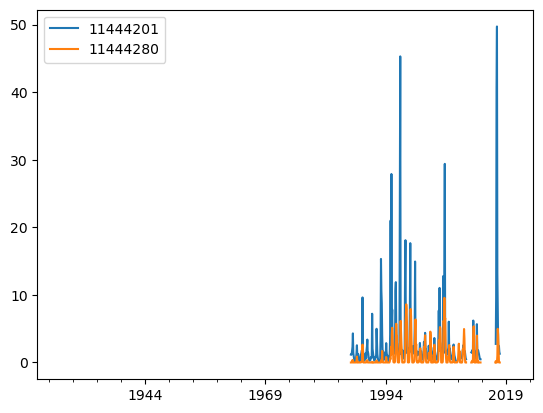

In [4]:
# Review I_RCK001, the only input data to RCK001 was USGS 11444201

# dont' pull USGS data, the USGS gage used for RCK 001 was discontinued in 2017
sl_usgs_stations = ['11444201','11444280']
sl_cdec_stations = ['AMF']
# pull USGS data
df_usgs_data_original, df_usgs_data_monthly_taf = pull_usgs_data(sl_usgs_stations, s_start_date, s_end_date)

# pull the cdec data
df_cdec_data_original, df_cdec_data_monthly_taf = pull_cdec_data(sl_cdec_stations, s_start_date, s_end_date)

# combine all the gauge data
df_gauge_data_original = pd.merge(df_usgs_data_original, df_cdec_data_original, how='outer', left_index=True, right_index=True)
df_gauge_data_monthly_taf = pd.merge(df_usgs_data_monthly_taf, df_cdec_data_monthly_taf, how='outer', left_index=True, right_index=True)

df_gauge_data_monthly_taf.rename(columns={'BEV': 'YB90'}, inplace=True)

# combine the new data with the previous data
df_full_data = read_previous_data(s_previous_data, df_gauge_data_monthly_taf)

# plot data for location
df_full_data[sl_usgs_stations].plot()

A plot of the combined previous and extended gage data, shows roughly 25 years of available data with signficant gaps

No gapfilling or evaporation datasets are used for this dataset

# Unimpair the gage data
Each unimpaired flow location has it's own function related to the gage number, 'unimpaired_11444201' in the 'unimpairment_functions.py' file
For Rock Creek unimpairment we need to add back flows diverted to the Rock Creek Powerhouse, this data is provided by USGS 11444280


[]

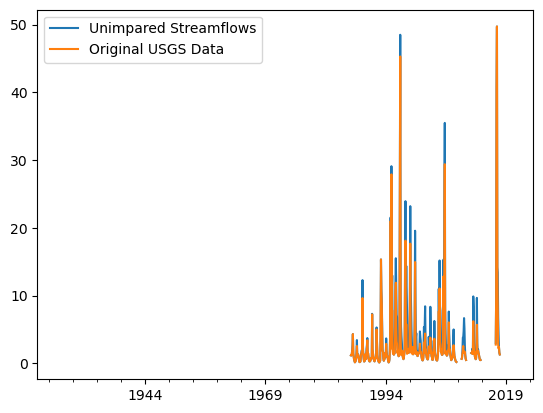

In [5]:

### unimpairing the data
df_unimpaired_data = pd.DataFrame()

df_unimpaired_data['11444201'] = unimpaired_11444201(df_full_data)

# drop the first row which is only for calculating storage differences
df_unimpaired_data.drop(index=df_unimpaired_data.index[0], inplace=True)

# redistribute negatives
df_pos_unimpaired_data = remove_negatives_timeseries(df_unimpaired_data)

# compare imppaired vs. unimpared data
fig,ax = plt.subplots()
df_unimpaired_data[sl_usgs_stations[0]].plot(ax=ax,label='unimpared')
df_full_data[sl_usgs_stations[0]].plot(ax=ax,label='original USGS Data')
ax.legend(labels=['Unimpared Streamflows','Original USGS Data'])
plt.plot()

The unimpaired flows are greater than the original gage flows, as expected with the addition of the 11444280 flows

Compare the data with the previous excel spreadsheet unimpaired data. This is found in the I_RCK001 spreadsheet, on the 'UNIMP Rock Creek 11444201' sheet

In [6]:
# confirm unimpairment matches spreadsheet values

s_sheet = 'UNIMP Rock Creek 11444201' 
df_excel_unimpaired = pd.read_excel(s_old_spreadsheet_fn,
                                    sheet_name = s_sheet,
                                    skiprows= 14,
                                    usecols='B:D',
                                    index_col=0)
df_combined_unimpaired = pd.concat([df_unimpaired_data,df_excel_unimpaired], axis=1)
df_combined_unimpaired['diff'] = df_combined_unimpaired['11444201'] - df_combined_unimpaired['TAF']

print(f'Maximum Difference Between Datasets: {df_combined_unimpaired['diff'].max()}'  )

Maximum Difference Between Datasets: 4.247937113177613e-09


Maximum difference between the datasets is very small and just a rounding difference between python and excel

# Extend the Dataset
Use data from FNF on the American River from CDEC (Station AMF). We'll use the unimpaired data from 1987 to 2008 to do the s-curve dissag w/ the AMF data. 
We also have data for the USGS gage for the end of wy 2017, so while this time period won't be used to develop the s-curve disagg, we'll keep it for the final extended unimpaired dataset (second line overwritting the extended data with the original unimpaired flows)



Extending flows...


[]

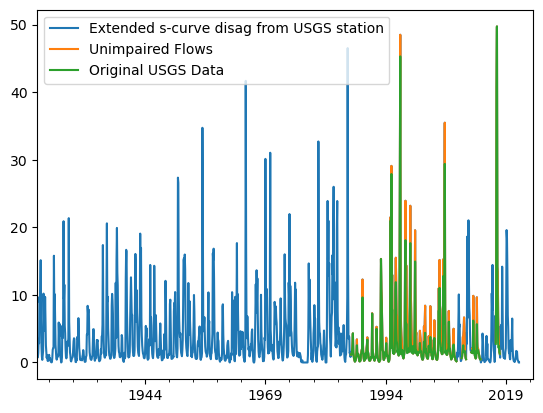

In [7]:
df_extended_data = pd.DataFrame()
df_synthetic_data = pd.DataFrame()

print("Extending flows...")

# extend all with the s-curve disaggregation
extend_data(df_full_data['AMF'], df_unimpaired_data['11444201'], df_extended_data, df_synthetic_data, 1987, 2008, True, '11444201', i_final_year=i_final_year)
# replace the end of wy 2017
df_extended_data.loc[datetime(2016, 11, 30): datetime(2017, 9, 30), '11444201'] = df_unimpaired_data.loc[datetime(2016, 11, 30): datetime(2017, 9, 30), '11444201']


# compare imppaired vs. unimpared data
fig,ax = plt.subplots()
df_extended_data[sl_usgs_stations[0]].plot(ax=ax,label='extended s-curve disagg')
df_unimpaired_data[sl_usgs_stations[0]].plot(ax=ax,label='unimpared')
df_full_data[sl_usgs_stations[0]].plot(ax=ax,label='original USGS Data')
ax.legend(labels=['Extended s-curve disag from USGS station','Unimpaired Flows','Original USGS Data'])
plt.plot()

In [8]:
# confirm disaggregation matches spreadsheet values

# confirm unimpairment matches spreadsheet values
s_sheet = 'MODELA' # sheet with scurve dissag
df_excel_scurve = pd.read_excel(s_old_spreadsheet_fn,
                                    sheet_name = s_sheet,
                                    skiprows= 7,
                                    usecols='AF:AG',
                                    index_col = 0)
df_combined_scurve = pd.concat([df_extended_data,df_excel_scurve], axis=1)
df_combined_scurve['diff'] = df_combined_scurve['11444201'] - df_combined_scurve['TAF']

print(df_combined_scurve.head())
print(f'Maximum Difference Between Datasets: {df_combined_unimpaired['diff'].max()}'  )

            11444201       TAF          diff
1921-10-31  0.796292  0.796292  8.737899e-12
1921-11-30  1.443420  1.443420  4.894840e-11
1921-12-31  3.488787  3.488787  5.247891e-11
1922-01-31  2.843710  2.843710  2.047695e-11
1922-02-28  9.713949  9.713949  2.175629e-10
Maximum Difference Between Datasets: 4.247937113177613e-09


# Calculate Rim Inflows
The python code calls a location specific Rim Inflow function, included in rim_inflow_functions.py  
For this location, the inflow location is seet to the the unimpaired flows rounded to two decimal places. Other locations are more complex

Calculating rim inflows...


[]

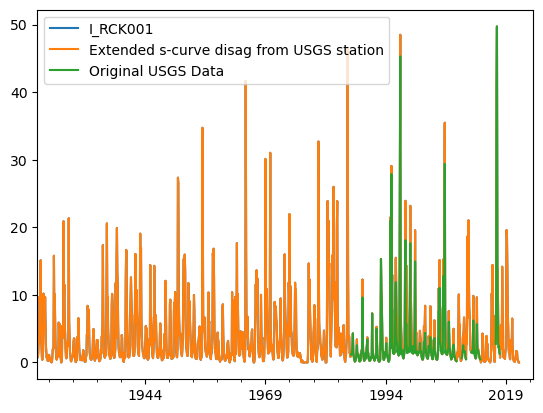

In [9]:
# final rim inflows
df_rim_inflows = pd.DataFrame()

print("Calculating rim inflows...")

I_RCK001(df_extended_data, df_rim_inflows)


# compare imppaired vs. unimpared data
fig,ax = plt.subplots()
df_rim_inflows['I_RCK001'].plot(ax=ax,label='I_RCK001')
df_extended_data[sl_usgs_stations[0]].plot(ax=ax,label='extended s-curve disagg')
df_full_data[sl_usgs_stations[0]].plot(ax=ax,label='original USGS Data')
ax.legend(labels=['I_RCK001','Extended s-curve disag from USGS station','Original USGS Data'])
plt.plot()

# Compare the python generated I_RCK001 Rim Inflow w/ the Previous Spreadsheet Dataset

In [10]:
# Compare with Previous Data
s_prev_rim_inflows_fn = "CS3_Sac_ReadAllInflowDatatoDSS_05.18.23.xlsm" # file path and name must be provided to plot/calculate comparison
s_prev_rim_inflow_sheet = "Inflows"
df_reference = pd.read_excel(s_prev_rim_inflows_fn, sheet_name=s_prev_rim_inflow_sheet, skiprows=[0,2,3,4,5,6,7,8,9,10,11],header=0, index_col=0, parse_dates=True)
df_diffs = abs(df_reference[df_rim_inflows.columns] - df_rim_inflows).max().to_frame('Max Difference')
df_diffs['Median Value - Original'] = df_reference[df_rim_inflows.columns].mean()
df_diffs['Median Value - Extension'] = df_rim_inflows.mean()

df_diffs['Max Percent Difference'] = (abs(df_reference[df_rim_inflows.columns] - df_rim_inflows)).max() / df_reference[df_rim_inflows.columns].mean()
print("Maximum differences:")
print(df_diffs.sort_values(by='Max Difference', ascending=False).to_string())

Maximum differences:
          Max Difference  Median Value - Original  Median Value - Extension  Max Percent Difference
I_RCK001             0.0                 4.044767                  4.044767                     0.0


The Maximum percent difference between the dataset is zero. No change from the spreadsheet to the python generated output.